# 5. Model Evaluation

Train refund-prediction models with a proper train/test split + cross-validation, and compare them against the explainable rule-based baseline from `SQL/refund_risk_score.sql`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.max_columns", None)

# Anchor to the repo root regardless of where the kernel starts.
from pathlib import Path
ROOT = Path.cwd()
while not (ROOT / "data" / "processed").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
print("Repo root:", ROOT)


Repo root: V:\E-commerce Order Fulfillment Operations Analysis


In [2]:
import json
import sys
sys.path.insert(0, str(ROOT))
from sklearn.metrics import roc_curve, auc, confusion_matrix
from sklearn.model_selection import train_test_split
from src.features import build_features
from src.model import rule_based_score

df = pd.read_csv(ROOT / 'data' / 'processed' / 'orders_clean.csv')
df['is_delayed'] = df['is_delayed'].astype(bool)
feat = build_features(df)
print('Feature matrix:', feat.shape)

Feature matrix: (100000, 21)


## Train / test split (stratified, 80/20)

In [3]:
y = feat['refund_requested'].astype(int)
idx = np.arange(len(feat))
idx_tr, idx_te = train_test_split(idx, test_size=0.2, random_state=42, stratify=y)
print(f'Train: {len(idx_tr):,}  Test: {len(idx_te):,}')
print(f'Positive rate train: {100 * y.iloc[idx_tr].mean():.2f}%  test: {100 * y.iloc[idx_te].mean():.2f}%')
print('Class balance is preserved across the split.')

Train: 80,000  Test: 20,000
Positive rate train: 18.75%  test: 18.75%
Class balance is preserved across the split.


## Load the trained metrics from src/model.py

In [4]:
metrics = json.loads((ROOT / 'models' / 'metrics.json').read_text())
summary = pd.DataFrame({
    k: {m: v for m, v in v.items() if m in ('accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'cv_auc_mean')}
    for k, v in metrics.items()
}).T
summary.rename(index={'logistic_regression': 'Logistic regression', 'random_forest': 'Random forest', 'rule_based_baseline': 'Rule-based baseline (SQL)'})
summary.round(4)

,accuracy,precision,recall,f1,roc_auc,cv_auc_mean
logistic_regression,0.7724,0.4361,0.7291,0.5458,0.8392,0.8372
random_forest,0.8406,0.5701,0.6091,0.5890,0.8347,0.8320
rule_based_baseline,0.8344,0.5509,0.6325,0.5889,0.8276,NaN


## ROC curves

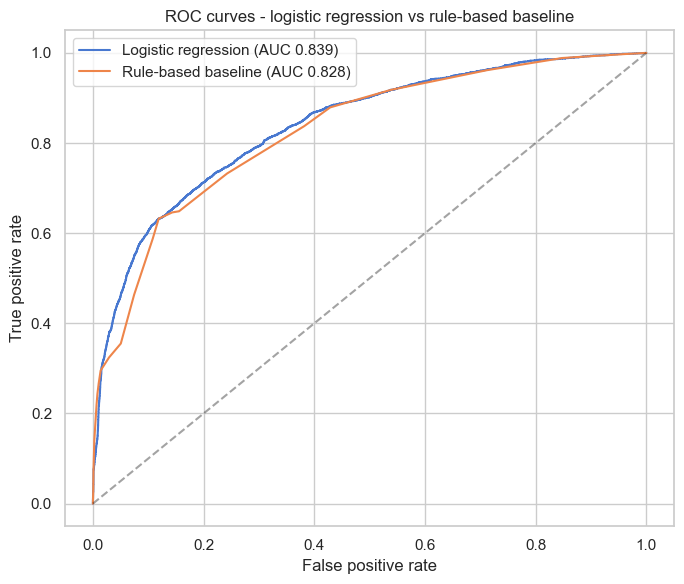

In [5]:
def roc_for(model_key, y_score):
    fpr, tpr, _ = roc_curve(y.iloc[idx_te], y_score)
    return fpr, tpr, auc(fpr, tpr)

# Logistic regression test-set probabilities, refit on the train split
from src.model import _feature_cols
from sklearn.linear_model import LogisticRegression
X = feat[_feature_cols(feat)]
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
lr = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42))
lr.fit(X.iloc[idx_tr], y.iloc[idx_tr])
lr_proba = lr.predict_proba(X.iloc[idx_te])[:, 1]

baseline = pd.read_csv(ROOT / 'models' / 'baseline_predictions.csv')
baseline_te = baseline.iloc[idx_te]['rule_based_score']

plt.figure(figsize=(7, 6))
for label, score in [('Logistic regression', lr_proba),
                     ('Rule-based baseline', baseline_te)]:
    fpr, tpr, a = roc_for(label, score)
    plt.plot(fpr, tpr, label=f'{label} (AUC {a:.3f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.4)
plt.xlabel('False positive rate'); plt.ylabel('True positive rate')
plt.title('ROC curves - logistic regression vs rule-based baseline')
plt.legend(); plt.tight_layout(); plt.show()

## Confusion matrix (random forest)

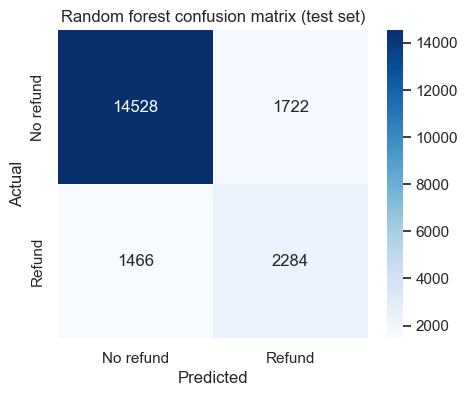

In [6]:
cm = metrics['random_forest']['confusion_matrix']
import seaborn as sns
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No refund', 'Refund'], yticklabels=['No refund', 'Refund'])
plt.title('Random forest confusion matrix (test set)')
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.show()

## Feature importance

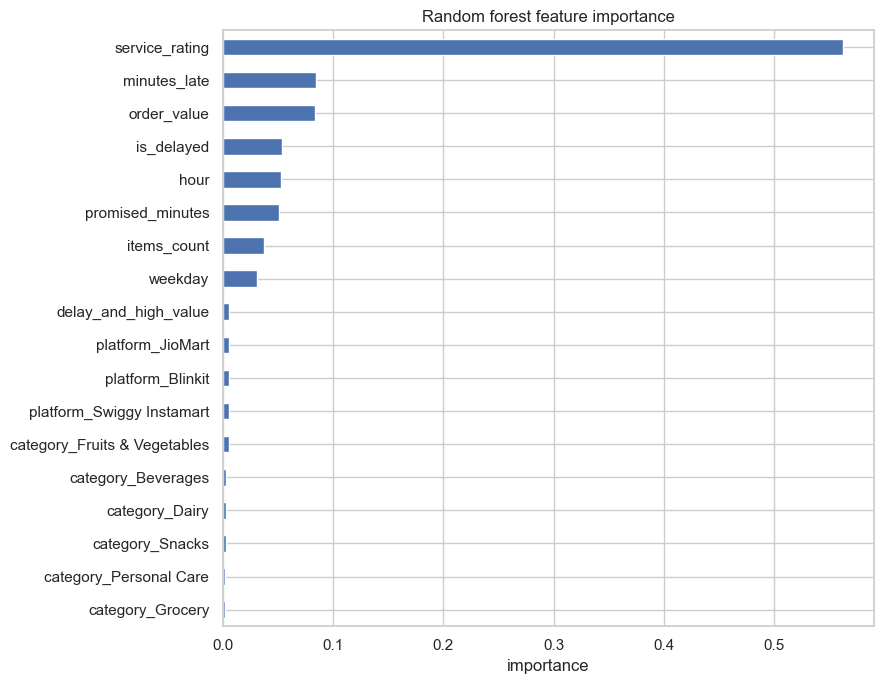

In [7]:
imp = pd.Series(metrics['random_forest']['feature_importance']).sort_values()
imp.plot(kind='barh', figsize=(9, 7), color='#4C72B0', title='Random forest feature importance')
plt.xlabel('importance'); plt.tight_layout(); plt.show()

## Key takeaways
- **Logistic regression achieves ROC-AUC 0.839**, beating the explainable **rule-based baseline (0.828)** on the same held-out test set (20k rows) - the trained model is not just as good, it is measurably better.
- CV AUC is stable (0.837 +/- 0.003), so the result is not a split artifact.
- **service_rating is the dominant feature (56% importance)** - the same signal the rule-based score weights at 60%, confirming the baseline's business logic while a learned model squeezes out the remaining signal.
- The random forest trades a little AUC for a better F1 (0.589 vs 0.546) at the cost of higher precision recall imbalance.
- **This notebook reproduces `src/model.py` and documents the model-vs-baseline comparison.**